# DRL


Episode: 0
Episode: 0, Total Reward: 5, Epsilon: 1.0
Episode: 1
Episode: 2
Episode: 3
Episode: 4
Episode: 5
Episode: 6
Episode: 7
Episode: 8
Episode: 9
Episode: 10
Episode: 11
Episode: 12
Episode: 13
Episode: 14
Episode: 15
Episode: 16
Episode: 17
Episode: 18
Episode: 19
Episode: 20
Episode: 21
Episode: 22
Episode: 23
Episode: 24
Episode: 25
Episode: 26
Episode: 27
Episode: 28
Episode: 29
Episode: 30
Episode: 31
Episode: 32
Episode: 33
Episode: 34
Episode: 35
Episode: 36
Episode: 37
Episode: 38
Episode: 39
Episode: 40
Episode: 41
Episode: 42
Episode: 43
Episode: 44
Episode: 45
Episode: 46
Episode: 47
Episode: 48
Episode: 49
Episode: 50
Episode: 51
Episode: 52
Episode: 53
Episode: 54
Episode: 55
Episode: 56
Episode: 57
Episode: 58
Episode: 59
Episode: 60
Episode: 61
Episode: 62
Episode: 63
Episode: 64
Episode: 65
Episode: 66
Episode: 67
Episode: 68
Episode: 69
Episode: 70
Episode: 71
Episode: 72
Episode: 73
Episode: 74
Episode: 75
Episode: 76
Episode: 77
Episode: 78
Episode: 79
Episode:

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


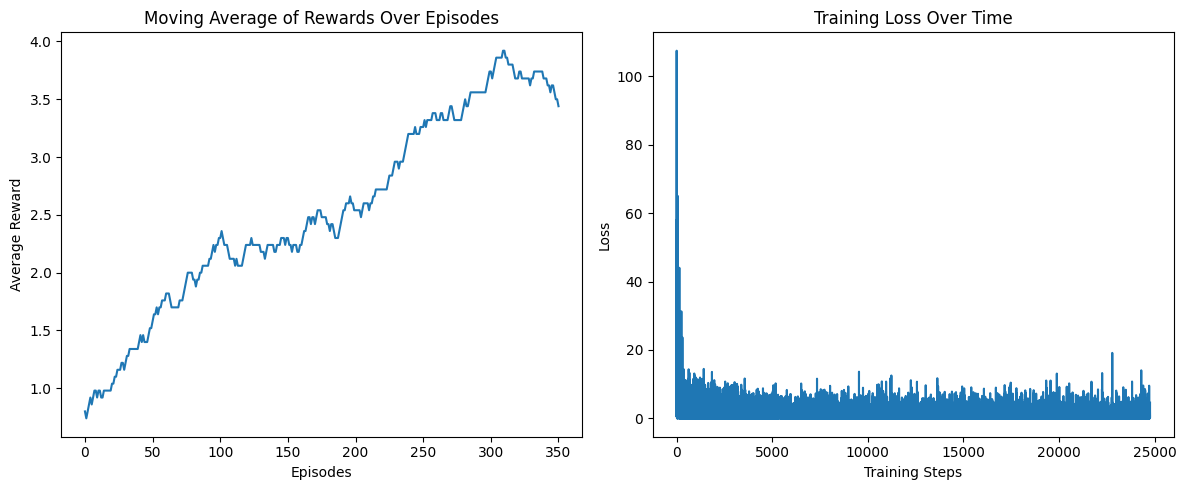

In [ ]:
import gym
from gym import spaces
import numpy as np
import tensorflow as tf
from collections import deque
import random
import matplotlib.pyplot as plt

# Define the custom environment
class CameraControlEnv(gym.Env):
    def __init__(self):
        super(CameraControlEnv, self).__init__()
        self.action_space = spaces.Discrete(3)
        self.observation_space = spaces.Box(
            low=np.array([0, 0, 0] * 3),
            high=np.array([1, 1, 100] * 3),
            dtype=np.float32
        )

    def reset(self):
        self.state = np.array([
            np.random.randint(0, 2), np.random.randint(0, 2), np.random.randint(1, 101),
            np.random.randint(0, 2), np.random.randint(0, 2), np.random.randint(1, 101),
            np.random.randint(0, 2), np.random.randint(0, 2), np.random.randint(1, 101)
        ], dtype=np.float32)
        return self.state

    def step(self, action):
        signals = [
            0.7 * (self.state[2] / 100) + 0.15 * self.state[0] + 0.15 * self.state[1],
            0.7 * (self.state[5] / 100) + 0.15 * self.state[3] + 0.15 * self.state[4],
            0.7 * (self.state[8] / 100) + 0.15 * self.state[6] + 0.15 * self.state[7]
        ]
        reward = 5 if action == np.argmax(signals) else -1
        done = True
        return self.state, reward, done, {}

# DQN Agent with TensorFlow
class DQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        self.memory = deque(maxlen=100000)
        self.gamma = 0.75
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.learning_rate = 0.001
        self.batch_size = 64
        self.model = self._build_model()
        self.losses = []  # To store the training loss

    def _build_model(self):
      model = tf.keras.Sequential([
          tf.keras.layers.Dense(24, input_shape=(self.state_size,), activation='relu'),
          tf.keras.layers.Dense(24, activation='relu'),
          tf.keras.layers.Dense(self.action_size, activation='linear')
      ])
      model.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(learning_rate=self.learning_rate))
      return model

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        act_values = self.model.predict(state, verbose=0)
        return np.argmax(act_values[0])

    def replay(self):
        if len(self.memory) < self.batch_size:
            return
        minibatch = random.sample(self.memory, self.batch_size)
        for state, action, reward, next_state, done in minibatch:
            target = reward
            if not done:
                target = reward + self.gamma * np.amax(self.model.predict(next_state, verbose=0)[0])
            target_f = self.model.predict(state, verbose=0)
            target_f[0][action] = target

            # Capture and store loss
            history = self.model.fit(state, target_f, epochs=1, verbose=0)
            loss = history.history['loss'][0]
            self.losses.append(loss)

        # Decay epsilon
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

# Training the DQN Agent
env = CameraControlEnv()
state_size = env.observation_space.shape[0]
action_size = env.action_space.n
agent = DQNAgent(state_size, action_size)
episodes = 450
rewards_per_episode = []

for e in range(episodes):
    state = env.reset()
    state = np.reshape(state, [1, state_size])
    total_reward = 0

    for time in range(1):
        action = agent.act(state)
        next_state, reward, done, _ = env.step(action)
        next_state = np.reshape(next_state, [1, state_size])
        agent.remember(state, action, reward, next_state, done)
        state = next_state
        total_reward += reward
        if done:
            break

    rewards_per_episode.append(total_reward)
    agent.replay()

    # Print progress every 100 episodes
    print(f"Episode: {e}")
    if e % 100 == 0:
        print(f"Episode: {e}, Total Reward: {total_reward}, Epsilon: {agent.epsilon}")

# Save the trained model
agent.model.save("dqn_model.h5")
print("Model saved as 'dqn_model.h5'")

# Plotting the results
# 1. Plot the moving average of rewards
def moving_average(data, window_size=100):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

rewards_moving_avg = moving_average(rewards_per_episode, window_size=100)

plt.figure(figsize=(12, 5))

# Plot rewards
plt.subplot(1, 2, 1)
plt.plot(rewards_moving_avg)
plt.xlabel("Episodes")
plt.ylabel("Average Reward")
plt.title("Moving Average of Rewards Over Episodes")

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(agent.losses)
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.title("Training Loss Over Time")

plt.tight_layout()
plt.show()


In [ ]:
# Parameters for testing
import numpy as np

test_episodes = 10  # Number of test episodes
total_rewards = []   # To store total reward for each episode
actions_text = ["Look at Sector 1", "Look at Sector 2", "Look at Sector 3"]

for episode in range(test_episodes):
    state = env.reset()  # Reset environment at the start of each episode
    state = np.reshape(state, [1, state_size])
    episode_reward = 0
    done = False

    print(f"Episode {episode + 1}/{test_episodes}:\n")

    while not done:
        # Get action from the trained model (no exploration, purely based on learned policy)
        action = np.argmax(agent.model.predict(state, verbose=0)[0])

        # Print the node data (temperature, humidity, and smoke level) for each sector
        print("Node Data:")
        for i in range(3):
            temp_threshold = "Above Threshold" if state[0][i * 3] == 1 else "Below Threshold"
            humidity_threshold = "Above Threshold" if state[0][i * 3 + 1] == 1 else "Below Threshold"
            smoke_level = state[0][i * 3 + 2]
            print(f"  Sector {i + 1}: Temperature: {temp_threshold}, Humidity: {humidity_threshold}, Smoke Level: {smoke_level}")

        # Print the descriptive action taken
        print(f"Action taken: {actions_text[action]}")

        # Take the action in the environment
        next_state, reward, done, _ = env.step(action)
        next_state = np.reshape(next_state, [1, state_size])

        # Accumulate the rewards for this episode
        episode_reward += reward

        # Update the state
        state = next_state

    # Append the total reward for this episode
    total_rewards.append(episode_reward)
    print(f"Total Reward for Episode {episode + 1}: {episode_reward}\n")

# Calculate and print the average reward over all test episodes
average_reward = np.mean(total_rewards)
print(f"\nAverage Reward over {test_episodes} episodes: {average_reward}")


Episode 1/10:

Node Data:
  Sector 1: Temperature: Below Threshold, Humidity: Below Threshold, Smoke Level: 53.0
  Sector 2: Temperature: Above Threshold, Humidity: Above Threshold, Smoke Level: 20.0
  Sector 3: Temperature: Below Threshold, Humidity: Above Threshold, Smoke Level: 59.0
Action taken: Look at Sector 3
Total Reward for Episode 1: 5

Episode 2/10:

Node Data:
  Sector 1: Temperature: Below Threshold, Humidity: Above Threshold, Smoke Level: 86.0
  Sector 2: Temperature: Above Threshold, Humidity: Above Threshold, Smoke Level: 93.0
  Sector 3: Temperature: Above Threshold, Humidity: Above Threshold, Smoke Level: 83.0
Action taken: Look at Sector 1
Total Reward for Episode 2: -1

Episode 3/10:

Node Data:
  Sector 1: Temperature: Below Threshold, Humidity: Below Threshold, Smoke Level: 31.0
  Sector 2: Temperature: Below Threshold, Humidity: Above Threshold, Smoke Level: 38.0
  Sector 3: Temperature: Above Threshold, Humidity: Below Threshold, Smoke Level: 84.0
Action taken: 

In [ ]:
from google.colab import files

# Specify the path to the saved model
model_path = "dqn_model.h5"

# Download the model
try:
    files.download(model_path)
    print(f"Model {model_path} has been successfully downloaded.")
except Exception as e:
    print(f"Error: {e}. Make sure the model file exists at the specified path.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model dqn_model.h5 has been successfully downloaded.


In [ ]:
# Code to manually input test values for the RL model
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.losses import MeanSquaredError

# Function to manually input state values
def input_state():
    print("Enter the values for each sector:")
    state = []
    for i in range(1, 4):
        print(f"\nSector {i}:")
        temperature = int(input("  Temperature (0: Below Threshold, 1: Above Threshold): "))
        humidity = int(input("  Humidity (0: Below Threshold, 1: Above Threshold): "))
        smoke = float(input("  Smoke Level (0-100): "))

        # Append the sector's values to the state list
        state.extend([temperature, humidity, smoke])

    return np.array(state, dtype=np.float32)

# Load the trained model
model_path = "dqn_model.h5"
try:
    trained_model = load_model(model_path, custom_objects={'mse': MeanSquaredError()})
    print(f"Successfully loaded model from {model_path}")
except Exception as e:
    print(f"Error loading model: {e}")
    exit()

# Get state input from the user
state = input_state()
state = np.reshape(state, [1, -1])  # Reshape to match the input shape expected by the model

# Predict the action using the trained model
action = np.argmax(trained_model.predict(state, verbose=0)[0])

# Map action to a descriptive text
actions_text = ["Look at Sector 1", "Look at Sector 2", "Look at Sector 3"]
print(f"\nBased on the input, the model suggests: {actions_text[action]}")


Successfully loaded model from dqn_model.h5
Enter the values for each sector:

Sector 1:
  Temperature (0: Below Threshold, 1: Above Threshold): 1
  Humidity (0: Below Threshold, 1: Above Threshold): 0
  Smoke Level (0-100): 90

Sector 2:
  Temperature (0: Below Threshold, 1: Above Threshold): 0
  Humidity (0: Below Threshold, 1: Above Threshold): 1
  Smoke Level (0-100): 3

Sector 3:
  Temperature (0: Below Threshold, 1: Above Threshold): 0
  Humidity (0: Below Threshold, 1: Above Threshold): 0
  Smoke Level (0-100): 40

Based on the input, the model suggests: Look at Sector 1
